# Probability of Default Modelling for Consumer Credit Risk
### A censoring-aware PD scorecard on 36-month consumer loans, validated out-of-time

---
## 01. Executive Summary

Consumer lenders must estimate, at application time, the probability that a borrower will default (PD). This project builds an interpretable PD scorecard on LendingClub consumer loan data (2.26M loans, 2007–2018).

**Key design decision:** later vintages are right-censored (their outcomes are not yet observable at the March-2019 data cutoff), so the modelling universe is restricted to loans whose **entire contractual term completed before the cutoff** — every outcome is genuinely observed, none assumed.

**Result:** a 12-feature WOE logistic scorecard, trained on 2012–2014 originations and validated **out-of-time** on 372,811 loans from 2015–Q1 2016: **AUC 0.671, Gini 0.342, KS 0.247**, with monotonic observed bad rates across four risk bands (7.9% → 30.9%) and stable discrimination across test vintages. A gradient-boosting challenger gained only ~0.024 Gini, supporting the interpretable champion for regulated credit decisioning.

## 02. Business Problem

Every consumer loan is a decision made under uncertainty: approve and risk a credit loss, or decline and lose the customer. A PD model quantifies that risk **using only information available at application**, enabling risk-based approval, pricing and portfolio monitoring.

Two failure modes make naive PD projects invalid, and both are addressed explicitly here:
1. **Target leakage** — using post-origination information (payments, recoveries) that would not exist at decision time.
2. **Right-censoring** — labelling loans whose outcome has not yet been observed.

In [1]:
import numpy as np, pandas as pd, warnings, os
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve

import kagglehub
path = kagglehub.dataset_download("wordsforthewise/lending-club")
file = os.path.join(path, "accepted_2007_to_2018Q4.csv.gz")
print("data at:", file)

100%|██████████| 1.26G/1.26G [00:54<00:00, 24.8MB/s]

Extracting files...


data at: /root/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3/accepted_2007_to_2018Q4.csv.gz


## 03. Data & Observation Window

LendingClub accepted-loans file: **2,260,701** loans issued Jan 2007 – Dec 2018. Latest recorded payment activity: **March 2019** — this is the *observation cutoff*: nothing after this date exists in the data.

A loan's outcome is only fully knowable if its whole term fits inside the window:
- **36-month loans:** eligible if issued on or before **2016-03-01**
- **60-month loans:** eligible if issued on or before **2014-03-01**

In [2]:
# 03/06. BUILD THE FULLY-OBSERVABLE MODELLING UNIVERSE
# Rule: issue_date + term must complete by the 2019-03-01 cutoff.
# Loans that cannot have finished are right-censored -> excluded.
feat_cols = ['term','home_ownership','verification_status','purpose','emp_length',
             'fico_range_low','acc_open_past_24mths','dti','avg_cur_bal',
             'loan_amnt','mths_since_recent_inq','inq_last_6mths','mort_acc',
             'annual_inc','revol_util','int_rate','grade','installment',
             'earliest_cr_line','open_acc','total_acc','delinq_2yrs','pub_rec']
usecols = feat_cols + ['loan_status','issue_d']
CUTOFF = pd.Timestamp('2019-03-01')

parts, n_total = [], 0
for chunk in pd.read_csv(file, usecols=usecols, chunksize=250000, low_memory=False):
    n_total += len(chunk)
    chunk['issue']  = pd.to_datetime(chunk['issue_d'], format='%b-%Y', errors='coerce')
    chunk['term_m'] = chunk['term'].str.extract(r'(\d+)').astype(float)
    chunk = chunk[chunk['issue'].notna() & chunk['term_m'].notna()]
    chunk['term_end'] = chunk['issue'] + chunk['term_m'].apply(lambda m: pd.DateOffset(months=int(m)))
    parts.append(chunk[chunk['term_end'] <= CUTOFF])
u = pd.concat(parts, ignore_index=True)
print(f"original rows           : {n_total:,}")
print(f"fully observable        : {len(u):,}  ({len(u)/n_total*100:.1f}%)")

original rows           : 2,260,701
fully observable        : 785,915  (34.8%)


## 04. Outcome Definition

The target is **default over the full contractual term**, on fully-observed loans only:

| Label | Raw loan_status values |
|---|---|
| **Good = 0** | Fully Paid; Does not meet the credit policy. Status:Fully Paid |
| **Bad = 1** | Charged Off; Default; Does not meet the credit policy. Status:Charged Off |
| **Excluded** | Current, In Grace Period, Late (16–30), Late (31–120) — stale/unresolved even inside the window (0.88%) |

No default *date* is required: status alone determines the label, and every label is observed rather than assumed.

In [3]:
# 04. TARGET

badS  = ['Charged Off','Default','Does not meet the credit policy. Status:Charged Off']
goodS = ['Fully Paid','Does not meet the credit policy. Status:Fully Paid']
u['target'] = np.where(u['loan_status'].isin(badS), 1,
              np.where(u['loan_status'].isin(goodS), 0, np.nan))
m = u[u['target'].notna()].copy()
m['yr'] = m['issue'].dt.year
print(f"final modelling universe: {len(m):,}")
print(f"  good: {(m['target']==0).sum():,} | bad: {(m['target']==1).sum():,} | bad rate {m['target'].mean():.4f}")
print(f"  36m: {(m['term_m']==36).sum():,} | 60m: {(m['term_m']==60).sum():,}")

final modelling universe: 779,026
  good: 660,654 | bad: 118,372 | bad rate 0.1519
  36m: 710,807 | 60m: 68,219


## 05. Censoring / Observability Analysis

Why the restriction matters: by 2017–2018, **59–86% of loans were still running** at the cutoff. Among the minority that had "matured", Fully Paid loans had closed at a median of 8–9 months — i.e. early prepayers, not loans observed to term. A test set drawn from those vintages is a biased sample of early resolvers, and metrics computed on it are unstable in an unknown direction.

**Design principle: outcome observability takes priority over test-set recency.** The trade-off (older vintages) is disclosed in Limitations.

## 06. Modelling Universe

| Category | Count | % |
|---|---:|---:|
| Original loans | 2,260,701 | 100.0 |
| Excluded — right-censored | 1,474,786 | 65.2 |
| Fully observable | 785,915 | 34.8 |
| Excluded — stale Current/Late/Grace | 6,889 | 0.9 of observable |
| **Final modelling universe** | **779,026** | |
| Good | 660,654 | 84.81 |
| Bad | 118,372 | 15.19 |

**Primary model scope: 36-month loans (710,807).** Fully-observed 60-month history ends at Q1-2014 originations, which cannot overlap an honest out-of-time window — so the 60-month product is out of scope, consistent with industry practice of product-level scorecards.

## 07. Leakage Audit

Every candidate variable was classified before modelling:

| Class | Variables | Decision |
|---|---|---|
| Known at origination | income, employment, home ownership, purpose, dti, loan amount, FICO, inquiries, account history, utilisation, public records | **KEEP (candidates)** |
| Post-origination | all payment / recovery / settlement / hardship / last-payment / outstanding-principal fields | **REMOVE — leakage** (never loaded) |
| Platform risk/pricing output | grade, sub_grade, int_rate, installment | **REMOVE** — the model is an *independent* view of borrower risk, not a reconstruction of the platform's pricing |
| Target source | loan_status | **REMOVE** — defines the target only |
| Split key | issue_d | used for the time split, never as a feature |

In [4]:
# 08/09. SCOPE TO 36M PRODUCT + FEATURE ENGINEERING
# Engineered features (credit logic):
#  - credit_hist_m  : months of credit history at application (experience)
#  - loan_to_income : requested amount vs annual income (debt burden)
# NOTE: an installment-to-income ratio was tested and REJECTED: it embeds
# the platform interest rate and was collinear with loan_to_income
# (coefficient sign flip on the training fit exposed it).

m36 = m[m['term_m']==36].copy()
m36['credit_hist_m']  = ((m36['issue'] - pd.to_datetime(m36['earliest_cr_line'], format='%b-%Y', errors='coerce')).dt.days/30.44)
m36['loan_to_income'] = m36['loan_amnt']/m36['annual_inc'].replace(0,np.nan)

# Time-based split: train on earlier vintages, test strictly later (out-of-time)
train = m36[m36['yr'].between(2012,2014)].copy()
test  = m36[(m36['yr']==2015) | ((m36['yr']==2016)&(m36['issue'].dt.month<=3))].copy()
print(f"TRAIN 2012-2014 : {len(train):,} loans, bad rate {train['target'].mean():.4f}")
print(f"OOT 2015-Q1'16  : {len(test):,} loans, bad rate {test['target'].mean():.4f}")

TRAIN 2012-2014 : 306,462 loans, bad rate 0.1325
OOT 2015-Q1'16  : 372,811 loans, bad rate 0.1518


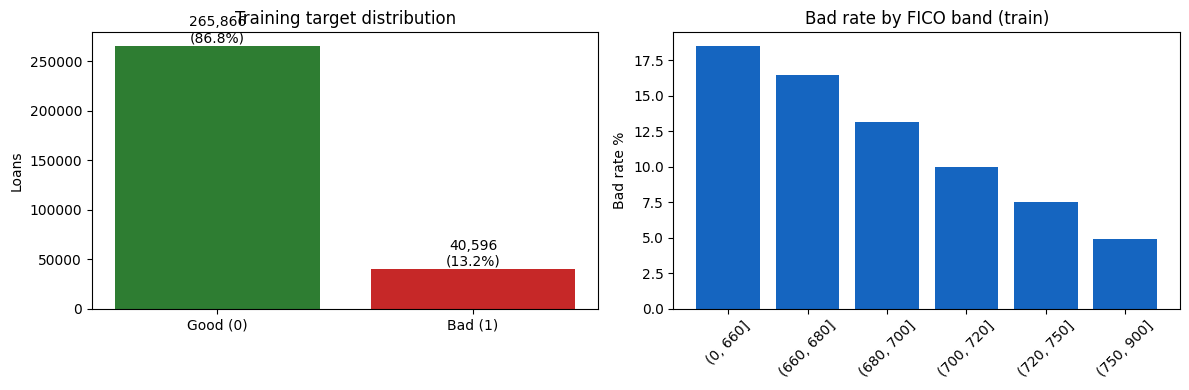

In [13]:

# 08. EDA — target balance and bad rate by key drivers (train only)

fig, ax = plt.subplots(1, 2, figsize=(12,4))
counts = train['target'].value_counts().sort_index()
ax[0].bar(['Good (0)','Bad (1)'], counts.values, color=['#2E7D32','#C62828'])
for i,v in enumerate(counts.values):
    ax[0].text(i, v, f'{v:,}\n({v/counts.sum()*100:.1f}%)', ha='center', va='bottom')
ax[0].set_title('Training target distribution'); ax[0].set_ylabel('Loans')

fico_band = pd.cut(train['fico_range_low'], [0,660,680,700,720,750,900])
br = train.groupby(fico_band)['target'].mean()*100
ax[1].bar(br.index.astype(str), br.values, color='#1565C0')
ax[1].set_title('Bad rate by FICO band (train)'); ax[1].set_ylabel('Bad rate %')
ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## 10. Weight of Evidence & Information Value

For each bin *i* of a feature: **WOE_i = ln(good%_i / bad%_i)** with a 0.5 adjustment against zero-count bins. Positive WOE = safer than average; negative = riskier. **IV = Σ (good%−bad%)·WOE** ranks each feature's separating power (<0.02 discard).

**Leakage control:** bin edges, WOE values and IVs are learned on the **training set only** and applied unchanged to the OOT sample. Missing values form an explicit bin; unseen OOT categories map to neutral WOE (0).

In [6]:
# ============================================================
# 10. TRAIN-ONLY BINNING, WOE, IV
# ============================================================
cat = ['home_ownership','verification_status','purpose','emp_length']
num = ['fico_range_low','acc_open_past_24mths','dti','avg_cur_bal','loan_amnt',
       'mths_since_recent_inq','inq_last_6mths','mort_acc','annual_inc','revol_util',
       'open_acc','total_acc','delinq_2yrs','pub_rec','credit_hist_m','loan_to_income']

edges = {}
for c in num:                                   # decile edges from TRAIN only
    _, e = pd.qcut(train[c], q=10, duplicates='drop', retbins=True)
    e[0], e[-1] = -np.inf, np.inf
    edges[c] = e

def binify(df):
    o = df.copy()
    for c in num:
        o[c+'_b'] = pd.cut(o[c], bins=edges[c]).cat.add_categories('MISSING')
        o[c+'_b'] = o[c+'_b'].fillna('MISSING')      # missing = own bin
    for c in cat:
        o[c] = o[c].fillna('MISSING')
    return o
trb, teb = binify(train), binify(test)

def woe_iv(df, f, target='target'):
    g = df.groupby(f)[target].agg(['count','sum']); g.columns=['tot','bad']
    g['good'] = g['tot'] - g['bad']
    g['bp'] = (g['bad']+0.5)/(g['bad']+0.5).sum()    # 0.5 zero-cell adjustment
    g['gp'] = (g['good']+0.5)/(g['good']+0.5).sum()
    g['woe'] = np.log(g['gp']/g['bp'])
    return g['woe'], ((g['gp']-g['bp'])*g['woe']).sum()

maps, ivs = {}, {}
for c in cat: maps[c], ivs[c] = woe_iv(trb, c)          # TRAIN only
for c in num: maps[c], ivs[c] = woe_iv(trb, c+'_b')     # TRAIN only

iv_t = pd.Series(ivs).sort_values(ascending=False)
print("Information Value (train-only):"); print(iv_t.round(4).to_string())

# select: IV >= 0.02; inst_to_income-type rate-contaminated features excluded by design
keep = [c for c in iv_t.index if iv_t[c] >= 0.02]
print("\nSelected features:", keep)

Information Value (train-only):
fico_range_low           0.1320
annual_inc               0.0870
avg_cur_bal              0.0653
acc_open_past_24mths     0.0552
dti                      0.0475
loan_to_income           0.0431
home_ownership           0.0390
mort_acc                 0.0379
mths_since_recent_inq    0.0304
purpose                  0.0226
revol_util               0.0207
inq_last_6mths           0.0203
credit_hist_m            0.0199
emp_length               0.0175
total_acc                0.0093
verification_status      0.0092
loan_amnt                0.0078
delinq_2yrs              0.0011
pub_rec                  0.0006
open_acc                 0.0003

Selected features: ['fico_range_low', 'annual_inc', 'avg_cur_bal', 'acc_open_past_24mths', 'dti', 'loan_to_income', 'home_ownership', 'mort_acc', 'mths_since_recent_inq', 'purpose', 'revol_util', 'inq_last_6mths']


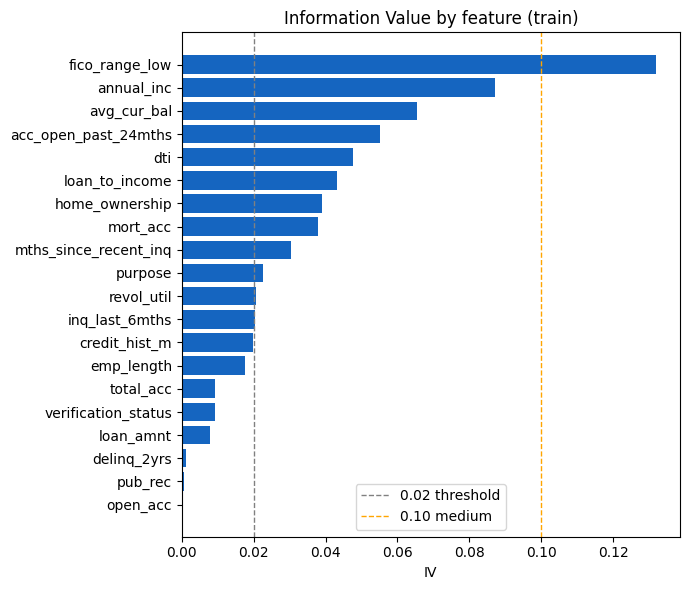

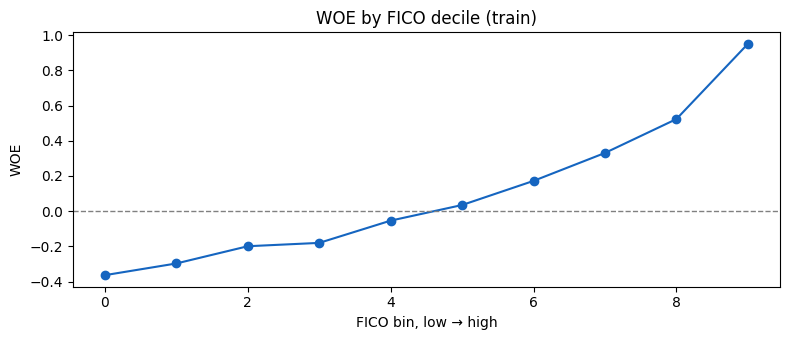

In [7]:
# IV ranking chart
plt.figure(figsize=(7,6))
ivp = iv_t.sort_values()
plt.barh(ivp.index, ivp.values, color='#1565C0')
plt.axvline(0.02, color='grey', ls='--', lw=1, label='0.02 threshold')
plt.axvline(0.10, color='orange', ls='--', lw=1, label='0.10 medium')
plt.title('Information Value by feature (train)'); plt.xlabel('IV'); plt.legend()
plt.tight_layout(); plt.show()

# WOE trend for FICO — expect a clean monotonic rise (low score risky -> high safe)
wf = maps['fico_range_low'].drop('MISSING', errors='ignore')
plt.figure(figsize=(8,3.5))
plt.plot(range(len(wf)), wf.values, marker='o', color='#1565C0')
plt.axhline(0, color='grey', ls='--', lw=1)
plt.title('WOE by FICO decile (train)'); plt.xlabel('FICO bin, low → high'); plt.ylabel('WOE')
plt.tight_layout(); plt.show()

## 11. Logistic PD Scorecard (Champion)

Logistic regression on WOE-transformed features. Chosen because credit decisioning must be **explainable to regulators and customers**: each feature contributes one interpretable coefficient. With high-WOE = safe and target 1 = bad, a well-behaved model has **uniformly negative coefficients** — a built-in multicollinearity check (this check caught and removed a collinear engineered ratio during development).

In [8]:
# 11. CHAMPION MODEL

def X_woe(dfb):
    X = pd.DataFrame(index=dfb.index)
    for c in keep:
        col = c if c in cat else c + '_b'
        X[c] = dfb[col].map(maps[c]).astype(float)
    return X.fillna(0)                      # unseen OOT categories -> neutral WOE

Xtr, Xte = X_woe(trb), X_woe(teb)
ytr, yte = trb['target'].values, teb['target'].values

champion = sm.Logit(ytr, sm.add_constant(Xtr)).fit(disp=0)
print(champion.summary())
print("\nAll coefficients negative:", bool((champion.params.drop('const') < 0).all()))

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               306462
Model:                          Logit   Df Residuals:                   306449
Method:                           MLE   Df Model:                           12
Date:                Sun, 16 Aug 2026   Pseudo R-squ.:                 0.04896
Time:                        20:12:51   Log-Likelihood:            -1.1397e+05
converged:                       True   LL-Null:                   -1.1984e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.8818      0.006   -337.986      0.000      -1.893      -1.871
fico_range_low           -0.6772      0.019    -35.949      0.000      -0.714      -0.640
annual_i

## 12. Gradient Boosting Challenger

A challenger benchmarks how much predictive power the interpretable champion leaves on the table. **Comparison caveat (disclosed):** the challenger used the full candidate feature set with fixed (untuned) hyperparameters, so this is a directional benchmark, not a perfectly controlled comparison.

In [9]:
# ============================================================
# 12. CHALLENGER
# ============================================================
raw = [c for c in num]
def X_raw(df):
    X = df[raw].copy()
    for c in cat:
        X = pd.concat([X, pd.get_dummies(df[c].fillna('MISSING'), prefix=c)], axis=1)
    return X
Xr_tr, Xr_te = X_raw(train), X_raw(test)
Xr_te = Xr_te.reindex(columns=Xr_tr.columns, fill_value=0)
med = Xr_tr.median(numeric_only=True)
Xr_tr, Xr_te = Xr_tr.fillna(med), Xr_te.fillna(med)

gb = GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42)
gb.fit(Xr_tr, ytr)

GradientBoostingClassifier(n_estimators=150, random_state=42)

## 13. Out-of-Time Validation

The decisive test: performance on originations from a **strictly later period** (2015–Q1 2016) than training (2012–2014) — the way banks validate, because the production question is whether the model holds on future applicants.

Model                 OOT AUC    Gini      KS
Logistic (WOE)         0.6710  0.3420  0.2473
GradientBoosting       0.6831  0.3662  0.2644


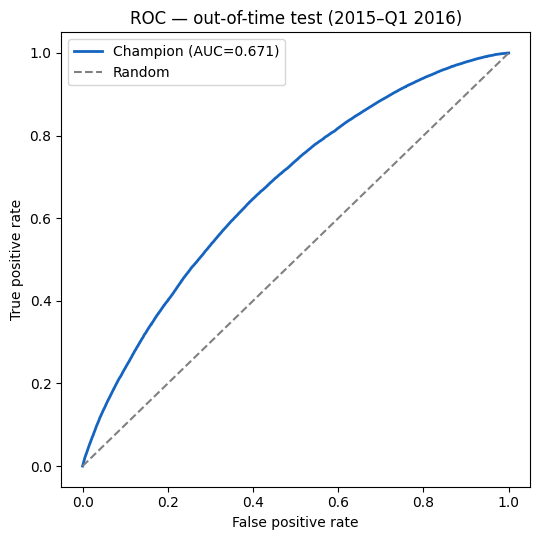

In [10]:
# ============================================================
# 13. OOT METRICS
# ============================================================
def metrics(y, p):
    a = roc_auc_score(y, p); f, t, _ = roc_curve(y, p)
    return a, 2*a - 1, max(t - f)

p_te  = champion.predict(sm.add_constant(Xte, has_constant='add'))
pg_te = gb.predict_proba(Xr_te)[:, 1]

a1,g1,k1 = metrics(yte, p_te); a2,g2,k2 = metrics(yte, pg_te)
print(f"{'Model':20s} {'OOT AUC':>8} {'Gini':>7} {'KS':>7}")
print(f"{'Logistic (WOE)':20s} {a1:8.4f} {g1:7.4f} {k1:7.4f}")
print(f"{'GradientBoosting':20s} {a2:8.4f} {g2:7.4f} {k2:7.4f}")

fpr, tpr, _ = roc_curve(yte, p_te)
plt.figure(figsize=(5.5,5.5))
plt.plot(fpr, tpr, color='#1565C0', lw=2, label=f'Champion (AUC={a1:.3f})')
plt.plot([0,1],[0,1], color='grey', ls='--', label='Random')
plt.title('ROC — out-of-time test (2015–Q1 2016)')
plt.xlabel('False positive rate'); plt.ylabel('True positive rate'); plt.legend()
plt.tight_layout(); plt.show()

## 14. Calibration & Stability

**Calibration:** ranking is strictly monotonic across predicted-PD deciles, but PDs run below observed bad rates (up to ~3pp in the top decile). Root cause is **base-rate drift**: the OOT vintages are genuinely worse (15.18% bad) than training vintages (13.25%). In production this is handled by **intercept recalibration** to the live portfolio; it is documented here rather than patched.

**Stability:** discrimination does not decay across test vintages — Gini 0.330 (2015H1) → 0.342 (2015H2) → 0.359 (2016Q1).

In [11]:
# ============================================================
# 14. CALIBRATION TABLE + VINTAGE STABILITY
# ============================================================
cal = pd.DataFrame({'p': p_te, 'y': yte})
cal['dec'] = pd.qcut(cal['p'], 10, labels=False, duplicates='drop')
ct = cal.groupby('dec').agg(pred=('p','mean'), obs=('y','mean'), n=('y','size'))
print("Calibration by predicted-PD decile (OOT):")
print((ct.assign(pred=ct['pred']*100, obs=ct['obs']*100)).round(2).to_string())

teb2 = teb.copy(); teb2['p'] = p_te.values
print("\nStability by OOT vintage:")
for lab, sub in [('2015H1', teb2[(teb2['yr']==2015)&(teb2['issue'].dt.month<=6)]),
                 ('2015H2', teb2[(teb2['yr']==2015)&(teb2['issue'].dt.month> 6)]),
                 ('2016Q1', teb2[teb2['yr']==2016])]:
    aa, gg, kk = metrics(sub['target'].values, sub['p'].values)
    print(f"  {lab}: n={len(sub):,}  bad={sub['target'].mean():.4f}  Gini={gg:.4f}  KS={kk:.4f}")

Calibration by predicted-PD decile (OOT):
      pred    obs      n
dec                     
0     4.06   3.97  37282
1     6.41   6.96  37281
2     8.16   9.35  37281
3     9.79  11.16  37281
4    11.41  13.13  37281
5    13.16  15.01  37281
6    15.11  17.55  37280
7    17.47  20.06  37282
8    20.72  23.71  37281
9    27.67  30.90  37281

Stability by OOT vintage:
  2015H1: n=120,790  bad=0.1512  Gini=0.3304  KS=0.2381
  2015H2: n=162,236  bad=0.1471  Gini=0.3422  KS=0.2485
  2016Q1: n=89,785  bad=0.1610  Gini=0.3585  KS=0.2590


## 15. Risk Segmentation

PD quantiles → four bands (40/30/20/10). Observed bad rates are strictly monotonic — the model output translates into a usable risk framework, not just a score.

                n  pop_%   pred    obs     bads  bad_%of_all
band                                                        
Low        149125   40.0   7.10   7.86  11721.0         20.7
Medium     111842   30.0  13.23  15.23  17033.0         30.1
High        74563   20.0  19.10  21.89  16319.0         28.8
Very High   37281   10.0  27.67  30.90  11518.0         20.4


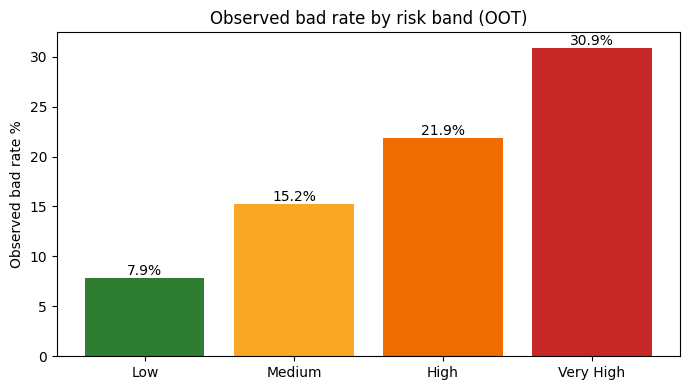

In [12]:
# ============================================================
# 15. RISK BANDS
# ============================================================
cal['band'] = pd.qcut(cal['p'], [0,.4,.7,.9,1.0], labels=['Low','Medium','High','Very High'])
rb = cal.groupby('band').agg(n=('y','size'), bads=('y','sum'), pred=('p','mean'), obs=('y','mean'))
rb['pop_%']  = (rb['n']/len(cal)*100).round(1)
rb['bad_%of_all'] = (rb['bads']/rb['bads'].sum()*100).round(1)
print(rb.assign(pred=(rb['pred']*100).round(2), obs=(rb['obs']*100).round(2))
        [['n','pop_%','pred','obs','bads','bad_%of_all']].to_string())

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(rb.index.astype(str), rb['obs']*100, color=['#2E7D32','#F9A825','#EF6C00','#C62828'])
for i,(b,o) in enumerate(zip(rb.index, rb['obs']*100)):
    ax.text(i, o, f'{o:.1f}%', ha='center', va='bottom')
ax.set_title('Observed bad rate by risk band (OOT)'); ax.set_ylabel('Observed bad rate %')
plt.tight_layout(); plt.show()

## 16. Business Application

Demonstrated directly: out-of-time risk rank-ordering; four-band segmentation with monotonic observed bad rates; default concentration — **the top two risk bands (30% of borrowers) contain 49.2% of all defaults**; identification of default drivers (FICO, recent account openings, inquiry recency, revolving utilisation, DTI, loan-to-income, purpose).

The model **could support**: risk-based approval cutoffs (e.g. manual review of the Very-High band), risk-based pricing tiers, portfolio monitoring via band-mix drift by vintage, and — extended with LGD/EAD — impairment inputs. No claim is made that lending decisions were changed.

## 17. Limitations

1. Marketplace-lending data, not proprietary bank underwriting data — population and process differ.
2. The full-observability rule limits usable vintages (≤ Q1 2016); the model is validated on a pre-2017 lending environment.
3. Primary scope is the 36-month product only; fully-observed 60-month history predates any honest OOT window.
4. Target is lifetime default over the loan term, not a fixed 12-month PD (the data contains no default dates).
5. OOT PDs are under-calibrated due to base-rate drift; production use would require intercept recalibration.
6. No macroeconomic variables; discriminatory performance does not by itself establish economic value.

## 18. Conclusion

An interpretable, leakage-controlled PD scorecard, built on a censoring-aware universe of 779,026 fully-observed loans and validated out-of-time on 372,811 later-vintage loans (Gini 0.342, KS 0.247), with stable discrimination across vintages and a monotonic four-band risk segmentation concentrating 49% of defaults in 30% of borrowers. The gradient-boosting challenger's ~0.024 Gini uplift did not justify surrendering interpretability for regulated credit decisioning.